Face shape: (1100, 845, 3)


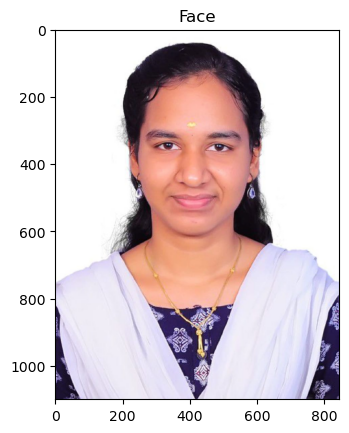

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Load face image
faceImage = cv2.imread("my.jpeg")
plt.imshow(faceImage[:,:,::-1]); plt.title("Face")
print("Face shape:", faceImage.shape)

Glass shape: (1000, 1000, 3)


Text(0.5, 1.0, 'Sunglass Color channels')

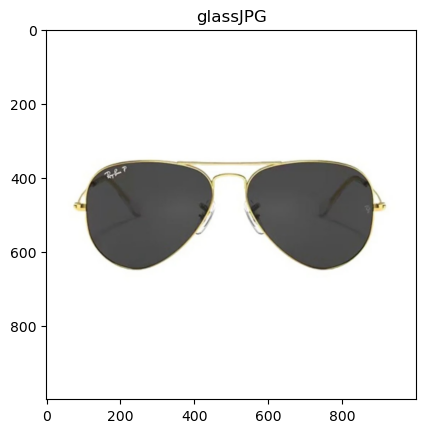

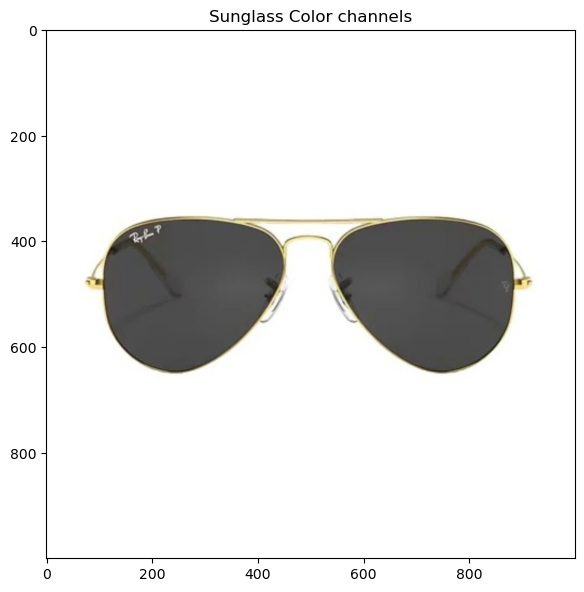

In [2]:
glassJPG = cv2.imread("sunglass.png")
plt.imshow(glassJPG[:,:,::-1]); plt.title("glassJPG")
print("Glass shape:", glassJPG.shape)

glassBGR = glassJPG[:,:,0:3]
glassGray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)
_, glassMask1 = cv2.threshold(glassGray, 240, 255, cv2.THRESH_BINARY_INV)  # detect non-white

plt.figure(figsize=[15,15])
#Show sunglasses color channels
plt.subplot(121)
plt.imshow(glassBGR[:,:,::-1])  # BGR → RGB
plt.title('Sunglass Color channels')


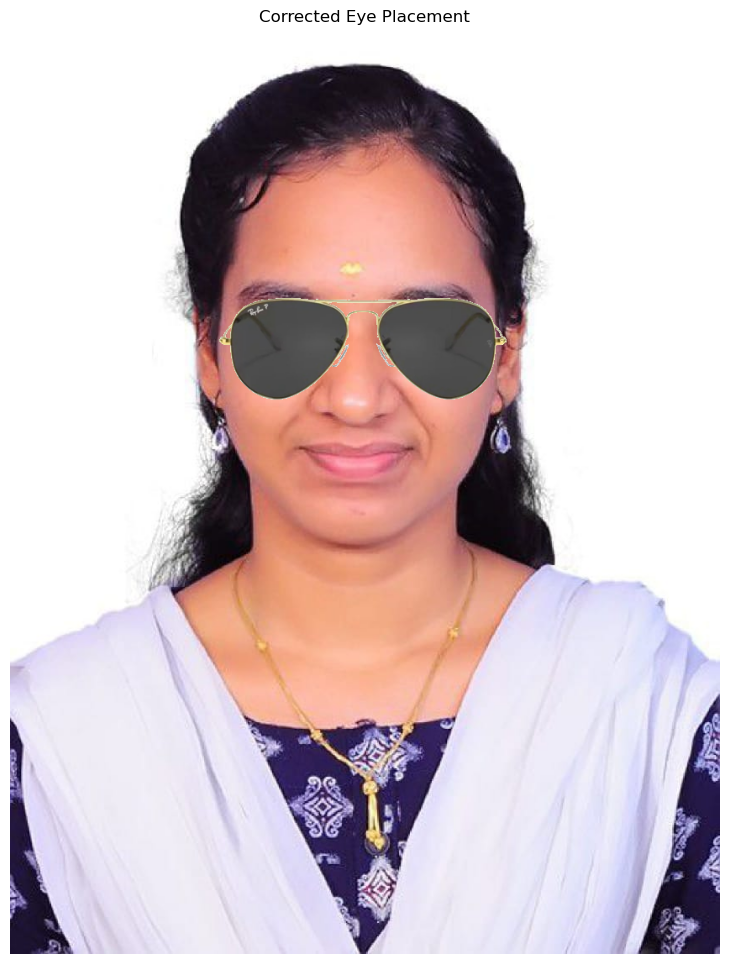

In [6]:

 # Fallback: If it's a 3-channel image, we create a mask for dark pixels
glass_rgb = glass_resized
gray = cv2.cvtColor(glass_resized, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray, 230, 255, cv2.THRESH_BINARY_INV)
alpha = mask / 255.0

# 4. PRECISE EYE POSITIONING (The Fix)
# For your specific h.jpg:
# x = 26% from left, y = 16% from top 
x = int(face_w * 0.26) 
y = int(face_h * 0.16) 

# 5. Define Region of Interest (ROI)
# We ensure the ROI stays within the image boundaries
y_end = min(y + new_h, face_h)
x_end = min(x + new_w, face_w)
roi = faceImage[y:y_end, x:x_end]

# Adjust glass/alpha dimensions if they were clipped by the boundary check
glass_rgb = glass_rgb[0:roi.shape[0], 0:roi.shape[1]]
alpha = alpha[0:roi.shape[0], 0:roi.shape[1]]

# 6. Smooth Blending
alpha_3d = alpha[:, :, np.newaxis]
# Formula: (Foreground * Alpha) + (Background * (1 - Alpha))
blended_roi = (glass_rgb * alpha_3d + roi * (1 - alpha_3d)).astype(np.uint8)

# 7. Place back and Display
faceImage[y:y_end, x:x_end] = blended_roi

plt.figure(figsize=(10, 12))
plt.imshow(cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Corrected Eye Placement")
plt.show()
